# 08. Customer Churn Prediction

## Objective

This notebook builds a machine learning model to predict customer churn using customer-level behavioral features.

### Input

- customer_features.csv

### Output

- customer_churn_predictions.csv
- churn_model.pkl

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

## 2. Load Customer Features Dataset

In [2]:
df = pd.read_csv(
    "../data/processed/customer_features.csv"
)

print("Dataset loaded successfully!")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (5878, 17)


,CustomerID,FirstPurchaseDate,LastPurchaseDate,TotalInvoices,TotalQuantity,TotalRevenue,AvgOrderValue,AvgBasketSize,AvgUniqueProducts,PreferredPurchaseHour,PreferredSeason,Country,Recency,Frequency,Monetary,Cluster,CustomerSegment
0,12346.0,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,2281.072353,2195.500000,11.647059,13,Summer,United Kingdom,326,12,77556.46,0,Regular Customers
1,12347.0,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,22.169054,425.594595,32.054054,14,Autumn,Iceland,2,8,4921.53,0,Regular Customers
2,12348.0,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,39.596078,674.117647,13.549020,14,Autumn,Finland,75,5,2019.40,0,Regular Customers
3,12349.0,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,25.306800,550.668571,59.834286,9,Autumn,Italy,19,4,4428.69,0,Regular Customers
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,19.670588,197.000000,17.000000,16,Winter,Norway,310,1,334.40,1,At-Risk Customers


## 3. Data Validation

In [3]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

print("\nDataset Shape:", df.shape)

print("\nMissing Values:", df.isnull().sum().sum())

print("Duplicate Rows:", df.duplicated().sum())

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             5878 non-null   float64
 1   FirstPurchaseDate      5878 non-null   str    
 2   LastPurchaseDate       5878 non-null   str    
 3   TotalInvoices          5878 non-null   int64  
 4   TotalQuantity          5878 non-null   int64  
 5   TotalRevenue           5878 non-null   float64
 6   AvgOrderValue          5878 non-null   float64
 7   AvgBasketSize          5878 non-null   float64
 8   AvgUniqueProducts      5878 non-null   float64
 9   PreferredPurchaseHour  5878 non-null   int64  
 10  PreferredSeason        5878 non-null   str    
 11  Country                5878 non-null   str    
 12  Recency                5878 non-null   int64  
 13  Frequency              5878 non-null   int64  
 14  Monetary               5878 non-null   float64


## 4. Create Churn Label

In [4]:
# Customers with Recency > 90 days are considered churned

df["Churn"] = df["Recency"].apply(
    lambda x: 1 if x > 90 else 0
)

print("Churn label created successfully!")

print("\nChurn Distribution:")

print(df["Churn"].value_counts())

Churn label created successfully!

Churn Distribution:
Churn
1    2989
0    2889
Name: count, dtype: int64


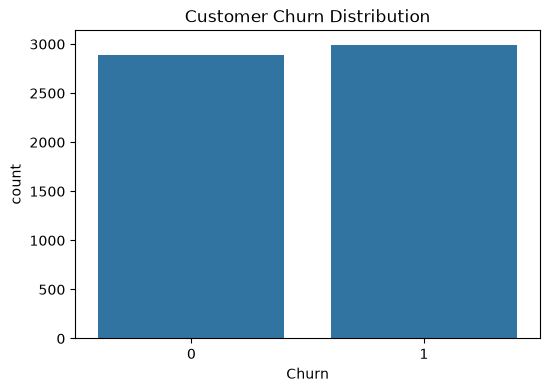

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

## 5. Feature Selection

In [6]:
X = df.drop(
    columns=[
        "CustomerID",
        "FirstPurchaseDate",
        "LastPurchaseDate",
        "CustomerSegment",
        "Country",
        "Churn",
        "Recency"          # Remove to avoid data leakage
    ]
)

y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print(X.columns.tolist())

Features Shape: (5878, 11)
Target Shape: (5878,)
['TotalInvoices', 'TotalQuantity', 'TotalRevenue', 'AvgOrderValue', 'AvgBasketSize', 'AvgUniqueProducts', 'PreferredPurchaseHour', 'PreferredSeason', 'Frequency', 'Monetary', 'Cluster']


## 6. Encode Categorical Features

In [7]:
# Convert categorical columns into numeric values

X = pd.get_dummies(
    X,
    columns=["PreferredSeason"],
    drop_first=True
)

print("Categorical features encoded successfully!")

print("New Feature Shape:", X.shape)

print(X.columns.tolist())

Categorical features encoded successfully!
New Feature Shape: (5878, 13)
['TotalInvoices', 'TotalQuantity', 'TotalRevenue', 'AvgOrderValue', 'AvgBasketSize', 'AvgUniqueProducts', 'PreferredPurchaseHour', 'Frequency', 'Monetary', 'Cluster', 'PreferredSeason_Spring', 'PreferredSeason_Summer', 'PreferredSeason_Winter']


## 7. Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (4702, 13)
Testing Set  : (1176, 13)


## 8. Model Training

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create model
churn_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model
churn_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


## 9. Model Prediction

In [10]:
# Predict on test set
y_pred = churn_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


## 10. Model Evaluation

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("Model Evaluation")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation
Accuracy : 0.8793
Precision: 0.9086
Recall   : 0.8478
F1 Score : 0.8772


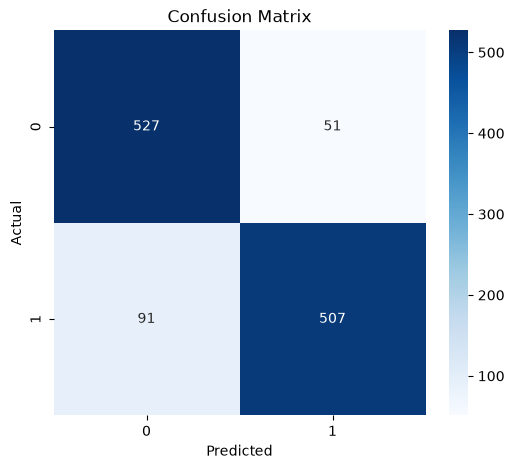

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 11. Generate Customer Churn Predictions

In [13]:
# Create a copy of the complete dataset
prediction_df = df.copy()

# Prepare features exactly as used during training
X_all = prediction_df.drop(
    columns=[
        "CustomerID",
        "FirstPurchaseDate",
        "LastPurchaseDate",
        "CustomerSegment",
        "Country",
        "Churn",
        "Recency"   # Removed to avoid leakage
    ]
)

# Encode categorical column
X_all = pd.get_dummies(
    X_all,
    columns=["PreferredSeason"],
    drop_first=True
)

# Align columns with training data
X_all = X_all.reindex(columns=X_train.columns, fill_value=0)

# Predict churn
prediction_df["PredictedChurn"] = churn_model.predict(X_all)

# Predict probability
prediction_df["ChurnProbability"] = churn_model.predict_proba(X_all)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


## 12. Save Predictions

In [14]:
dashboard_predictions = prediction_df[
    [
        "CustomerID",
        "Country",
        "CustomerSegment",
        "PredictedChurn",
        "ChurnProbability"
    ]
]

dashboard_predictions.to_csv(
    "../data/processed/customer_churn_predictions.csv",
    index=False
)

print("customer_churn_predictions.csv saved successfully!")

print("Shape:", dashboard_predictions.shape)

dashboard_predictions.head()

customer_churn_predictions.csv saved successfully!
Shape: (5878, 5)


,CustomerID,Country,CustomerSegment,PredictedChurn,ChurnProbability
0,12346.0,United Kingdom,Regular Customers,0,0.245
1,12347.0,Iceland,Regular Customers,0,0.025
2,12348.0,Finland,Regular Customers,0,0.280
3,12349.0,Italy,Regular Customers,0,0.040
4,12350.0,Norway,At-Risk Customers,1,0.995


# 13. Save Model

## Objective

Save the trained Random Forest churn prediction model for future inference and deployment in the RetailPulse application.

In [15]:
import joblib

joblib.dump(
    churn_model,
    "../models/churn_model.pkl"
)

print("✅ churn_model.pkl saved successfully!")

✅ churn_model.pkl saved successfully!


## 14. Business Insights

### Key Findings

- A Random Forest Classifier was developed to predict customer churn.
- The model achieved approximately **88% accuracy**, demonstrating strong predictive performance.
- Customers with higher purchasing frequency and monetary value were generally less likely to churn.
- Churn probability scores help identify high-risk customers for targeted retention campaigns.
- The generated prediction dataset can be directly integrated into the Streamlit dashboard for customer analytics and churn monitoring.

## 15. Summary

This notebook successfully developed a customer churn prediction model using customer-level behavioral features.

### Input

- customer_features.csv

### Outputs

- customer_churn_predictions.csv
- churn_model.pkl

### Model Performance

- Accuracy : 87.93%
- Precision : 90.86%
- Recall : 84.78%
- F1 Score : 87.72%

### Next Notebook

10_Dashboard_Dataset_Preparation.ipynb